In [1]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 

In [37]:
df =pd.read_csv(r"c:\Users\Admin\Documents\DataSets\cars.csv",encoding='Latin')

In [38]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [39]:
df.shape

(11914, 16)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [41]:
df.sample(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
2287,GMC,Canyon,2015,regular unleaded,305.0,6.0,AUTOMATIC,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,24,17,549,36950
6095,Volkswagen,Jetta,2015,premium unleaded (recommended),210.0,4.0,MANUAL,front wheel drive,4.0,"Factory Tuner,Performance",Midsize,Sedan,33,23,873,29280
9248,Toyota,Sienna,2017,regular unleaded,296.0,6.0,AUTOMATIC,front wheel drive,4.0,NaN,Large,Passenger Minivan,27,19,2031,40830
9592,Chevrolet,Silverado 1500,2016,regular unleaded,355.0,8.0,AUTOMATIC,four wheel drive,4.0,NaN,Large,Crew Cab Pickup,22,16,1385,53015
1298,BMW,ActiveHybrid X6,2010,premium unleaded (required),480.0,8.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Luxury,Performance,Hybrid",Midsize,4dr SUV,19,17,3916,88900


In [42]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

## Handling Null Values 

In [43]:
df['Engine Fuel Type'].isnull().mean()*100

np.float64(0.02518045996306866)

In [44]:
df['Engine Fuel Type']=df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

In [45]:
df['Engine HP'].isnull().mean()*100

np.float64(0.5791505791505791)

<Axes: xlabel='Engine HP', ylabel='Count'>

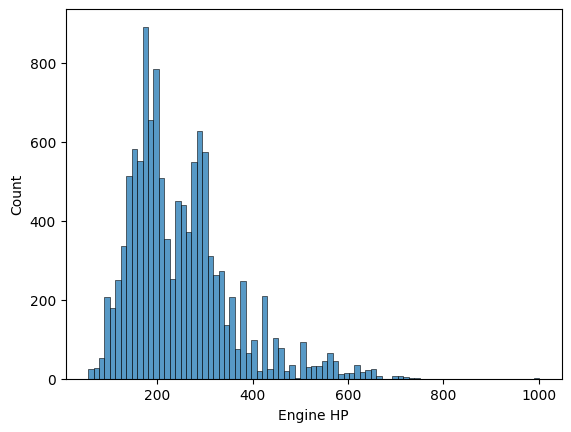

In [46]:
sns.histplot(df['Engine HP'])

In [47]:
df.groupby(df['Engine HP'].isna())['MSRP'].mean() # missing carries a signal (missing value --> lower the MSRP)

Engine HP
False    40547.195610
True     48756.014493
Name: MSRP, dtype: float64

In [48]:
df['Engine_HP_missing'] = df['Engine HP'].isna().astype(int)

In [49]:
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())

In [50]:
df['Market Category'].isnull().mean()*100  # 31% of data values are missing 

np.float64(31.408427060600975)

In [51]:
df['Market Category']=df['Market Category'].fillna('Unknown')

In [54]:
df['Market Category'].value_counts()

Market Category
Unknown                                            3742
Crossover                                          1110
Flex Fuel                                           872
Luxury                                              855
Luxury,Performance                                  673
                                                   ... 
Crossover,Exotic,Luxury,High-Performance              1
Crossover,Exotic,Luxury,Performance                   1
Performance,Hybrid                                    1
Exotic,Luxury,High-Performance,Hybrid                 1
Flex Fuel,Factory Tuner,Luxury,High-Performance       1
Name: count, Length: 72, dtype: int64

In [17]:
df['Engine Cylinders'].isnull().mean()*100 # 25% of data val are missing 

np.float64(0.2518045996306866)

In [18]:
df['Engine Cylinders']=df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())

In [19]:
df['Engine Cylinders'].mean()

np.float64(5.629763303676347)

<Axes: xlabel='Engine Cylinders', ylabel='Count'>

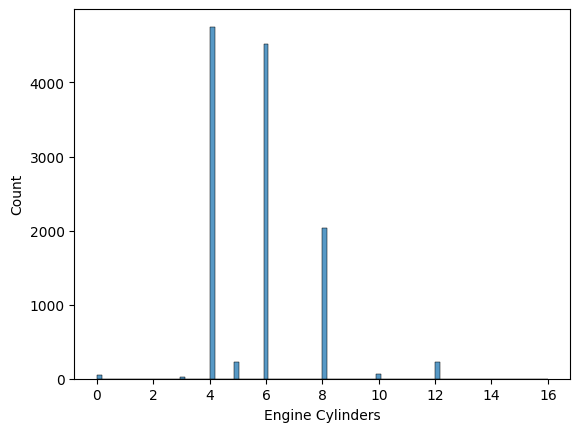

In [20]:
sns.histplot(df['Engine Cylinders'])

In [21]:
df['Number of Doors']=df['Number of Doors'].fillna(3)

In [22]:
df.isnull().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
Engine_HP_missing    0
dtype: int64

# MSRP


In [66]:
df['MSRP'].skew() #Msrp is highly skewed

np.float64(11.771987129334969)

<Axes: xlabel='MSRP', ylabel='Count'>

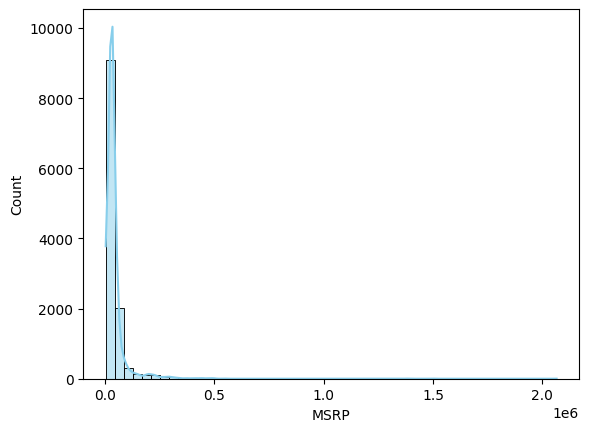

In [65]:
sns.histplot(df['MSRP'], bins=50, color='skyblue',kde=True) 

applying log transformation here for normal distribution

In [76]:
df['log_MSRP']=np.log1p(df['MSRP'])

In [ ]:
df['log_MSRP'].skew() # normally distributed

np.float64(-0.917867806703907)

<Axes: xlabel='log_MSRP', ylabel='Count'>

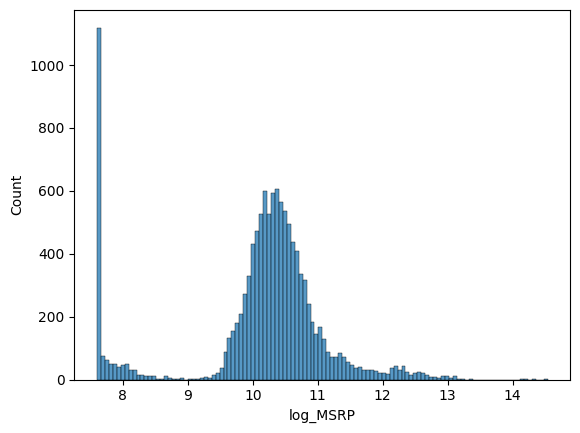

In [85]:
sns.histplot(df['log_MSRP'])

# Engine HP

In [ ]:
df['Engine HP'].skew() # right skewed

np.float64(1.2980337634502168)

<Axes: xlabel='Engine HP', ylabel='Count'>

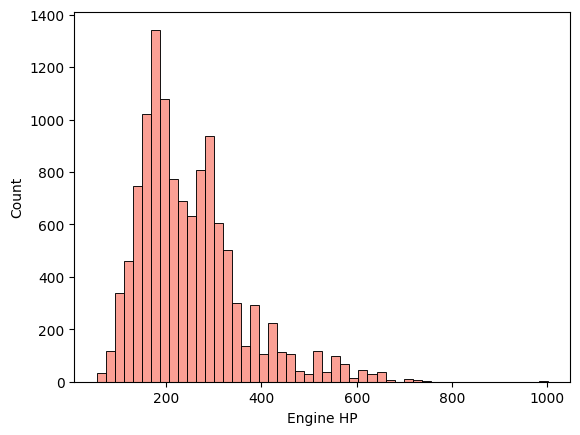

In [24]:
sns.histplot(df['Engine HP'], bins=50, color='salmon')

In [79]:
df['log_Engine_HP'] = np.log1p(df['Engine HP'])

<Axes: xlabel='log_Engine_HP', ylabel='Count'>

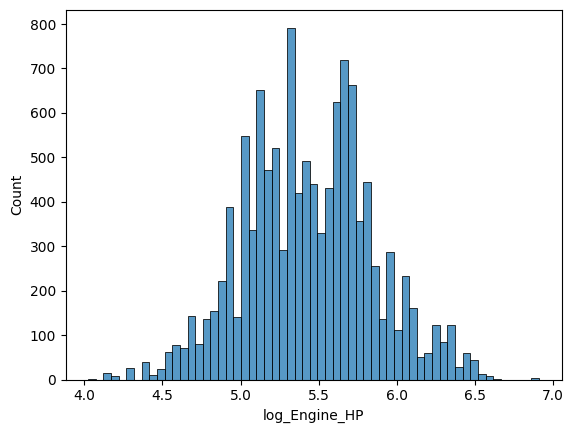

In [80]:
sns.histplot(df['log_Engine_HP'])

In [83]:
df['highway MPG'].skew() # highly right skew

np.float64(7.573931188779522)

In [84]:
df['highway MPG']

0        26
1        28
2        28
3        28
4        28
         ..
11909    23
11910    23
11911    23
11912    23
11913    26
Name: highway MPG, Length: 11914, dtype: int64

<Axes: xlabel='highway MPG', ylabel='Count'>

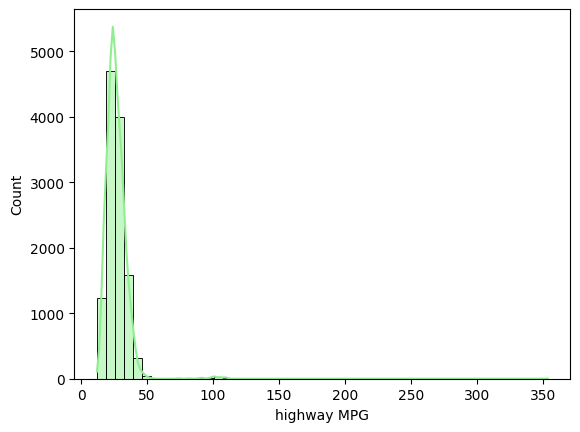

In [81]:
sns.histplot(df['highway MPG'], bins=50, color='lightgreen',kde=True)

In [ ]:
with pd.option_context('display.max_rows', None):
    scrolable=df[df['highway MPG']>60][['Make', 'Model', 'Year', 'highway MPG']]
    print(scrolable)

               Make                   Model  Year  highway MPG
539            FIAT                    500e  2015          108
540            FIAT                    500e  2016          103
541            FIAT                    500e  2017          103
1119           Audi                      A6  2017          354
1680  Mercedes-Benz  B-Class Electric Drive  2015           82
1681  Mercedes-Benz  B-Class Electric Drive  2016           82
1682  Mercedes-Benz  B-Class Electric Drive  2017           82
1983      Chevrolet                 Bolt EV  2017          110
1984      Chevrolet                 Bolt EV  2017          110
3716     Volkswagen                  e-Golf  2015          105
3717     Volkswagen                  e-Golf  2015          105
3718     Volkswagen                  e-Golf  2016          105
3719     Volkswagen                  e-Golf  2016          105
4705          Honda                  Fit EV  2013          105
4706          Honda                  Fit EV  2014      

In [57]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP', 'Engine_HP_missing'],
      dtype='object')

In [58]:
df['Year'].value_counts()

Year
2015    2170
2016    2157
2017    1668
2014     589
2012     387
2009     379
2013     366
2008     349
2007     345
2010     298
2011     285
2003     238
2004     235
2005     213
1993     209
2002     205
2006     205
1992     177
1997     175
2001     168
1994     163
1998     154
1991     152
1995     135
1996     131
1990     123
1999     120
2000     118
Name: count, dtype: int64

In [63]:
df['Make'].nunique()

48